<a href="https://colab.research.google.com/github/LukaszRoszyk/lecture1/blob/main/pum6_klasyfikacjabinarna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wczytanie danych

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Wczytanie danych (zgodnie z obrazkiem)
data = load_breast_cancer()
y = data.target
X = data.data

# Konwersja do DataFrame dla ułatwienia analizy (opcjonalne, ale bardzo pomocne)
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

In [ ]:
# 1. Sprawdź liczbę wszystkich przypadków
total_cases = X.shape[0]
print(f"1. Liczba wszystkich przypadków: {total_cases}")

1. Liczba wszystkich przypadków: 569


In [ ]:
# 2. Sprawdź liczbę przypadków raka złośliwego
malignant_cases = (y == 0).sum()
print(f"2. Liczba przypadków raka złośliwego: {malignant_cases}")

2. Liczba przypadków raka złośliwego: 212


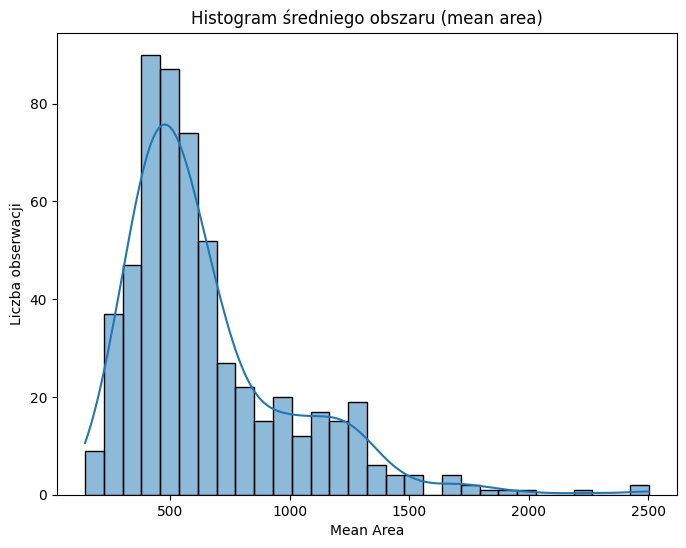

In [ ]:
# 3. Narysuj histogram średniego obszaru (mean area)
plt.figure(figsize=(8, 6))
sns.histplot(df['mean area'], bins=30, kde=True)
plt.title('Histogram średniego obszaru (mean area)')
plt.xlabel('Mean Area')
plt.ylabel('Liczba obserwacji')
plt.show()

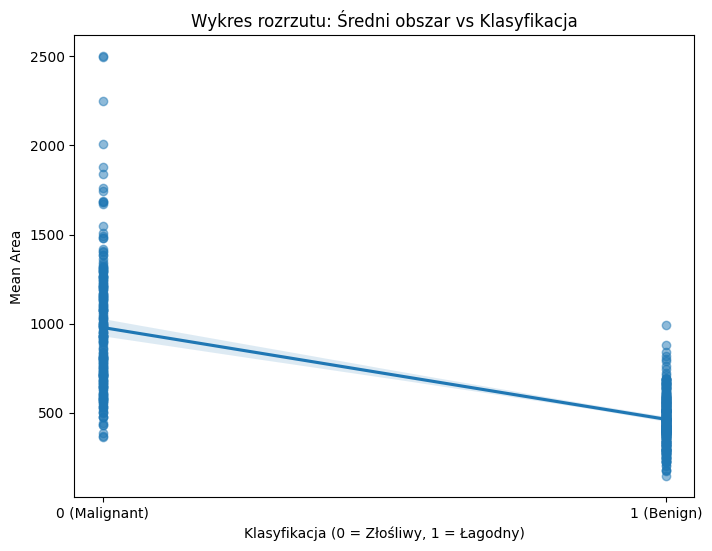

In [ ]:
# 4. Narysuj wykres rozrzutu (scatterplot) średniego obszaru od klasyfikacji
plt.figure(figsize=(8, 6))
sns.regplot(x='target', y='mean area', data=df, scatter_kws={'alpha':0.5})
plt.title('Wykres rozrzutu: Średni obszar vs Klasyfikacja')
plt.xlabel('Klasyfikacja (0 = Złośliwy, 1 = Łagodny)')
plt.ylabel('Mean Area')
plt.xticks([0, 1], ['0 (Malignant)', '1 (Benign)'])
plt.show()

Podział danych i Standaryzacja

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Podział na zbiór treningowy (70%) i testowy (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standaryzacja danych
scaler = StandardScaler()

# Dopasowanie i transformacja danych treningowych
X_train_scaled = scaler.fit_transform(X_train)

# Transformacja danych testowych
X_test_scaled = scaler.transform(X_test)

Budowa modelu regresji logistycznej

In [ ]:
from sklearn.linear_model import LogisticRegression

# Inicjalizacja i trenowanie modelu regresji logistycznej
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

Wizualizacja - Macierz pomyłek

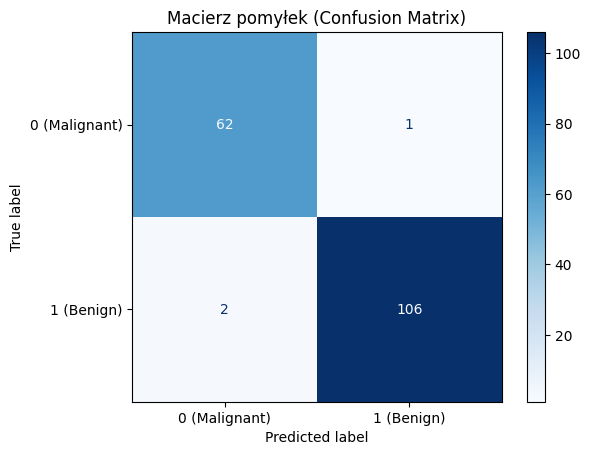

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generowanie przewidywań przez model
y_pred = model.predict(X_test_scaled)

# Tworzenie macierzy pomyłek
cm = confusion_matrix(y_test, y_pred)

# Rysowanie wykresu
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0 (Malignant)', '1 (Benign)'])
disp.plot(cmap='Blues')
plt.title('Macierz pomyłek (Confusion Matrix)')
plt.show()

Wizualizacja - Krzywa ROC

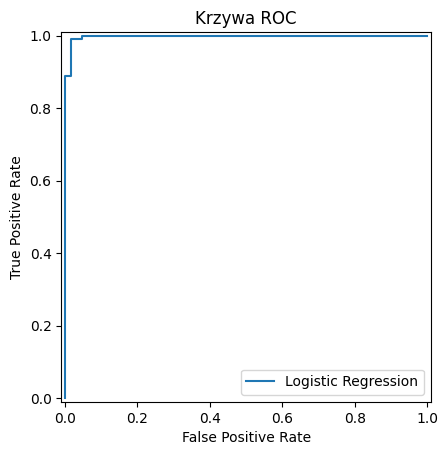

In [ ]:
from sklearn.metrics import roc_curve, RocCurveDisplay

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Obliczanie parametrów krzywej ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Rysowanie wykresu
disp_roc = RocCurveDisplay(fpr=fpr, tpr=tpr, estimator_name='Logistic Regression')
disp_roc.plot()
plt.title('Krzywa ROC')
plt.show()

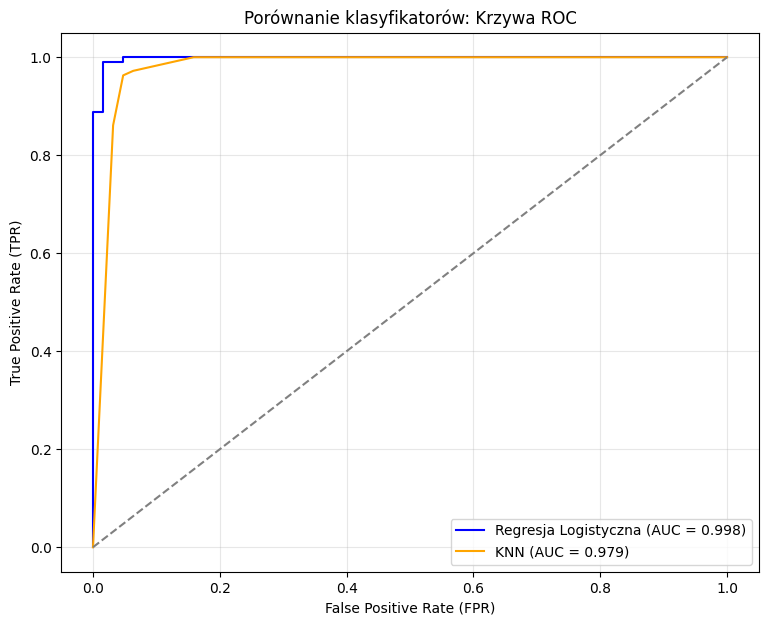

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc

# 1. przygotowaie danych
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Trenowanie obu klasyfikatorów
# Model 1: Regresja Logistyczna
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Model 2: K-Najbliższych Sąsiadów (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 3. Pobranie prawdopodobieństw dla klasy 1 (Benign) z obu modeli
y_prob_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

# 4. Obliczenie wartości do krzywej ROC oraz wskaźnika AUC
# Dla Regresji Logistycznej
fpr_log_reg, tpr_log_reg, thresholds_log = roc_curve(y_test, y_prob_log_reg)
auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

# Dla KNN
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

# 5. Rysowanie wspólnego wykresu porównawczego
plt.figure(figsize=(9, 7))

# Wykres Regresji Logistycznej
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Regresja Logistyczna (AUC = {auc_log_reg:.3f})', color='blue')

# Wykres KNN
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})', color='orange')

# Linia losowego klasyfikatora (tzw. baseline) - przerywana przekątna
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.title('Porównanie klasyfikatorów: Krzywa ROC')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

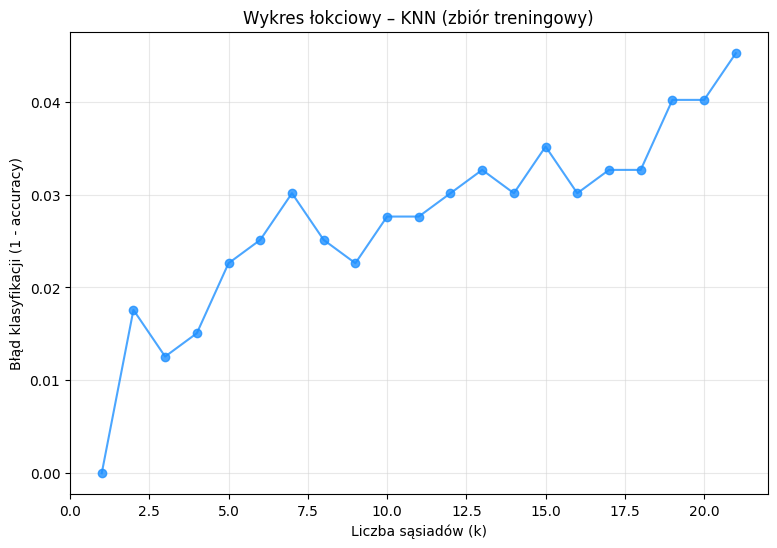

In [ ]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Listy na zapisywanie wyników
error_rates = []
k_range = range(1, 22) # Sprawdzamy k od 1 do 21

for i in k_range:
    # Tworzenie i trenowanie modelu dla danego k
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)

    # Przewidywanie NA ZBIORZE TRENINGOWYM
    error = 1 - knn.score(X_train_scaled, y_train)
    error_rates.append(error)

# Rysowanie wykresu
plt.figure(figsize=(9, 6))
plt.plot(k_range, error_rates, color='dodgerblue', marker='o', linestyle='-', alpha=0.8)

plt.title('Wykres łokciowy – KNN (zbiór treningowy)')
plt.xlabel('Liczba sąsiadów (k)')
plt.ylabel('Błąd klasyfikacji (1 - accuracy)')

# Dostosowanie siatki i osi
plt.grid(True, linestyle='-', alpha=0.5, color='lightgray')
plt.show()

Zysk informacyjny (petal width <= 0.5):  0.8643
Zysk informacyjny (petal width <= 0.38): 0.6195
Wniosek: Podział na poziomie 0.5 jest lepszy (wyższy zysk informacyjny).


<Figure size 1000x1000 with 0 Axes>

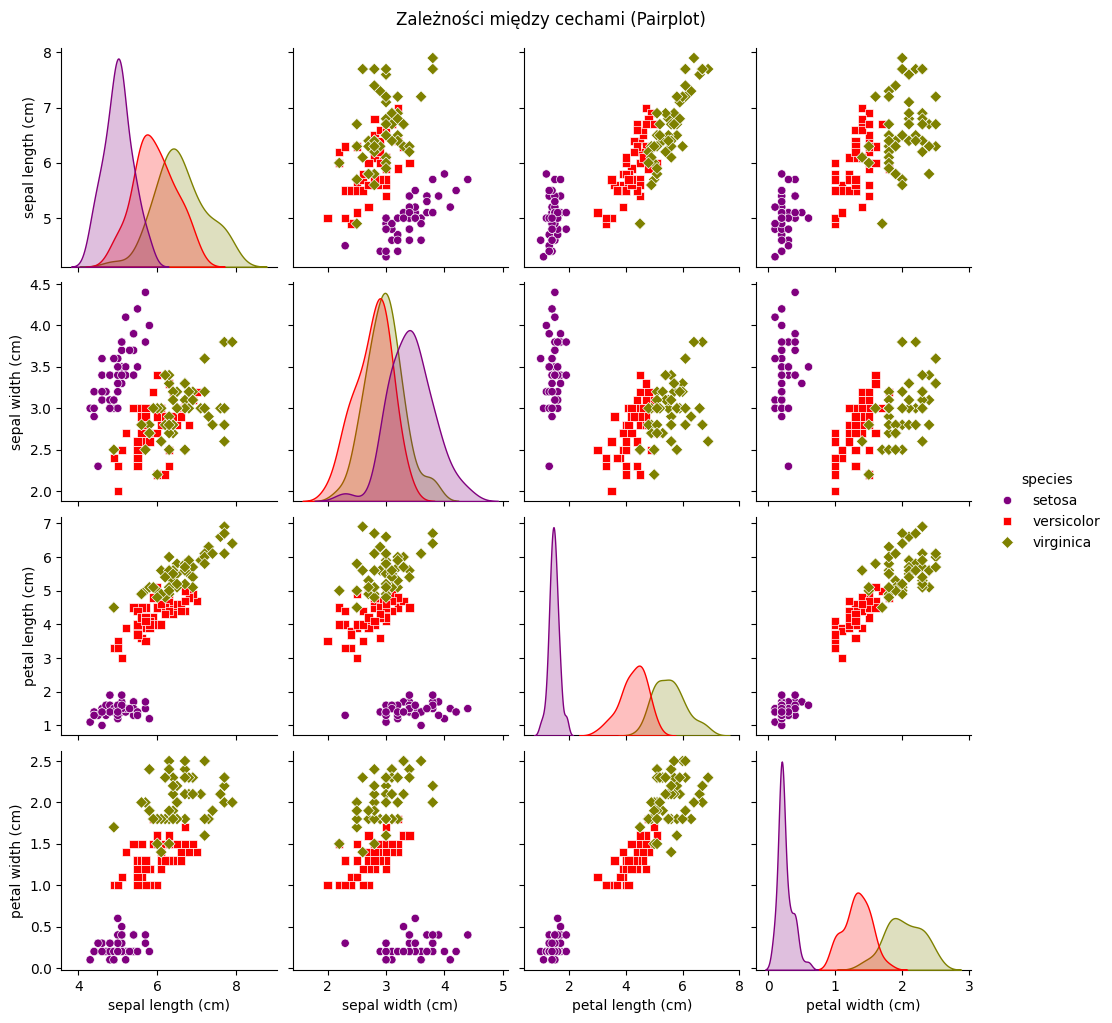

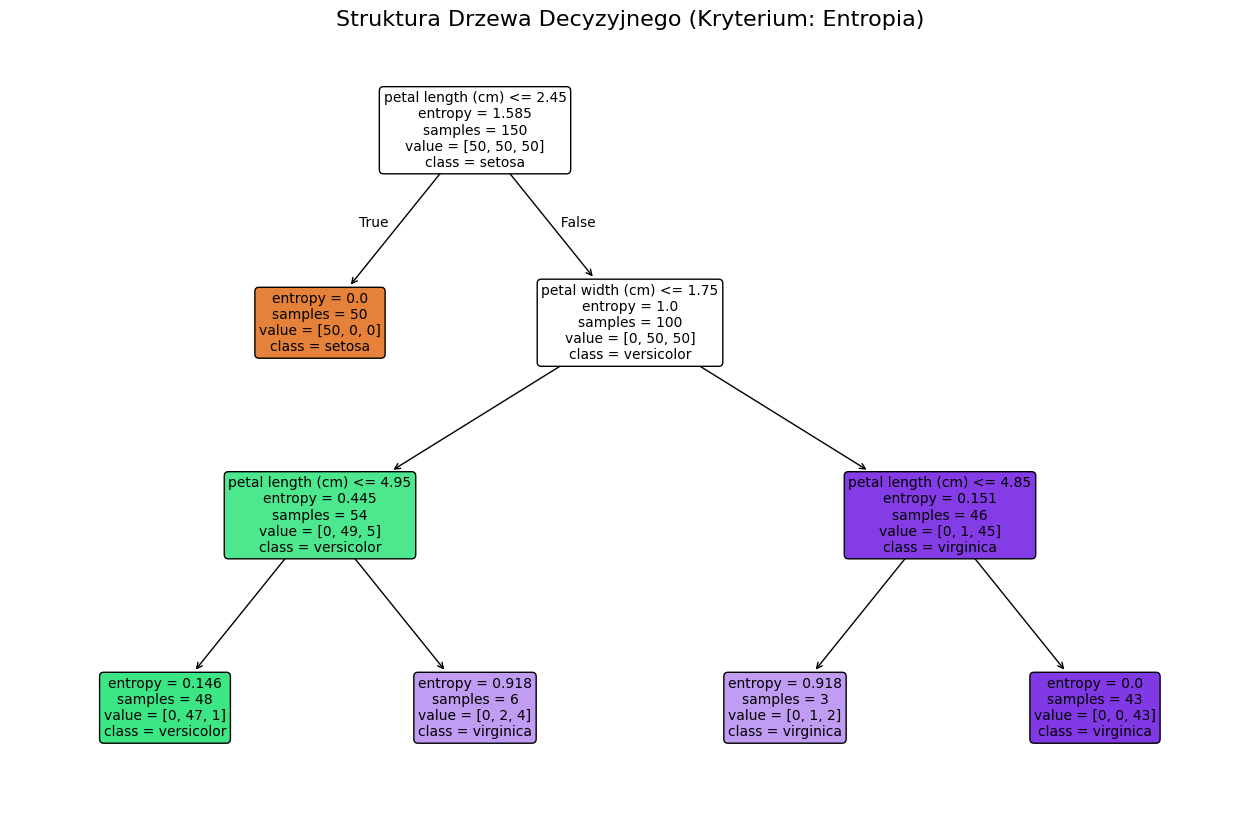

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Wczytanie danych
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Obliczenie zysku informacyjnego
def entropy(y_subset):
    if len(y_subset) == 0:
        return 0
    _, counts = np.unique(y_subset, return_counts=True)
    probs = counts / len(y_subset)
    return -np.sum(probs * np.log2(probs))

def info_gain(y_full, y_left, y_right):
    h_full = entropy(y_full)
    p_left = len(y_left) / len(y_full)
    p_right = len(y_right) / len(y_full)
    h_after = p_left * entropy(y_left) + p_right * entropy(y_right)
    return h_full - h_after

petal_width = X[:, 3]

# Obliczenie podziałów
mask_a = petal_width <= 0.5
mask_b = petal_width <= 0.38

ig_a = info_gain(y, y[mask_a], y[~mask_a])
ig_b = info_gain(y, y[mask_b], y[~mask_b])

print(f"Zysk informacyjny (petal width <= 0.5):  {ig_a:.4f}")
print(f"Zysk informacyjny (petal width <= 0.38): {ig_b:.4f}")
if ig_a > ig_b:
    print("Wniosek: Podział na poziomie 0.5 jest lepszy (wyższy zysk informacyjny).")
else:
    print("Wniosek: Podział na poziomie 0.38 jest lepszy (wyższy zysk informacyjny).")

# Wykres Pairplot
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in y]

plt.figure(figsize=(10, 10))
sns.pairplot(df, hue='species', palette='brg', markers=["o", "s", "D"])
plt.suptitle("Zależności między cechami (Pairplot)", y=1.02)
plt.show()

# Struktura Drzewa Decyzyjnego
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt_entropy.fit(X, y)

plt.figure(figsize=(16, 10))
plot_tree(dt_entropy,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Struktura Drzewa Decyzyjnego (Kryterium: Entropia)", fontsize=16)
plt.show()